# Étape 1 — Nettoyage & Feature Engineering
## Projet MLOps — Home Credit Default Risk

**Fichiers utilisés :**
- `application_train.csv` → données d'entraînement (avec TARGET)

# 1. Imports & Configuration

In [1]:
# numpy and pandas for data manipulation
import numpy as np
import pandas as pd 

# sklearn preprocessing for dealing with categorical variables
from sklearn.preprocessing import LabelEncoder

# File system manangement
import os

# matplotlib and seaborn for plotting
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH   = '/Users/veron/p6-MLFlow/'
OUTPUT_PATH = '/Users/veron/p6-MLFlow/'

print('✅ Imports OK')

✅ Imports OK


# 2. Chargement & Exploration

## a. Distribution de la Target

In [2]:
train = pd.read_csv(DATA_PATH + 'application_train.csv')
train['nan_count'] = train.isnull().sum(axis=1)

train = train.groupby('TARGET', group_keys=False).apply(
    lambda x: x.nsmallest(int(len(x) * 0.16), 'nan_count')
).reset_index(drop=True)

train = train.drop(columns=['nan_count'])

print(f'Train : {train.shape[0]:,} lignes × {train.shape[1]} colonnes')
print(f'\nDistribution TARGET :')
print(train['TARGET'].value_counts(normalize=True).round(3))
print(f'\nDéséquilibre : {train["TARGET"].mean()*100:.1f}% de défauts')

Train : 49,201 lignes × 122 colonnes

Distribution TARGET :
TARGET
0    0.919
1    0.081
Name: proportion, dtype: float64

Déséquilibre : 8.1% de défauts


/var/folders/tc/d7sx2drn7hn1b805l3sxnmlm0000gn/T/ipykernel_28207/1432108730.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train = train.groupby('TARGET', group_keys=False).apply(


In [3]:
app_train = pd.read_csv(DATA_PATH + 'application_train.csv')
print('Training data shape: ', app_train.shape)
app_train.head()

Training data shape:  (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


---

On a la variable TARGET, indiquant 0 : le prêt a été remboursé ou 1 : le prêt n’a pas été remboursé. 

---

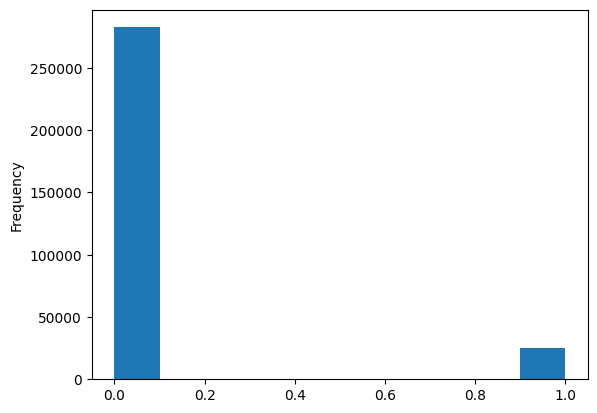

In [4]:
app_train['TARGET'].value_counts()
app_train['TARGET'].astype(int).plot.hist();

**D’après ces informations, nous voyons qu’il s’agit d’un problème de classe déséquilibré. Il y a beaucoup plus de prêts qui ont été remboursés à temps que de prêts qui n’ont pas été remboursés.**

## b. Les valeurs manquantes

In [5]:
def missing_values_table(df):
        # Total missing values
        mis_val = df.isnull().sum()
        
        # Percentage of missing values
        mis_val_percent = 100 * df.isnull().sum() / len(df)
        
        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
        
        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})
        
        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        
        # Print some summary information
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"      
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")
        
        # Return the dataframe with missing information
        return mis_val_table_ren_columns

In [6]:
# Missing values statistics
missing_values = missing_values_table(app_train)
missing_values.head(20)

Your selected dataframe has 122 columns.
There are 67 columns that have missing values.


,Missing Values,% of Total Values
COMMONAREA_MEDI,214865,69.9
COMMONAREA_AVG,214865,69.9
COMMONAREA_MODE,214865,69.9
NONLIVINGAPARTMENTS_MEDI,213514,69.4
NONLIVINGAPARTMENTS_MODE,213514,69.4
NONLIVINGAPARTMENTS_AVG,213514,69.4
FONDKAPREMONT_MODE,210295,68.4
LIVINGAPARTMENTS_MODE,210199,68.4
LIVINGAPARTMENTS_MEDI,210199,68.4
LIVINGAPARTMENTS_AVG,210199,68.4


**Lors de la construction de nos modèles, nous devrons remplir ces valeurs manquantes (appelées imputation). Dans les travaux ultérieurs, nous utiliserons des modèles tels que XGBoost qui peuvent gérer les valeurs manquantes sans avoir besoin d’imputation. Une autre option serait de supprimer les colonnes avec un pourcentage élevé de valeurs manquantes, bien qu’il soit impossible de savoir à l’avance si ces colonnes seront utiles pour notre modèle. Par conséquent, nous garderons toutes les colonnes pour l’instant.**

## c .Types de colonnes

Regardons le nombre de colonnes de chaque type de données. `int64` et `float64` sont des variables quantitative ([qui peuvent être soit discrètes, soit continues] `objet` les colonnes contiennent des chaînes de caractères et sont des caractéristiques catégorielles. 

In [7]:
app_train.dtypes.value_counts()

float64    65
int64      41
object     16
Name: count, dtype: int64

In [8]:
# Number of unique classes in each object column
app_train.select_dtypes('object').apply(pd.Series.nunique, axis = 0)

NAME_CONTRACT_TYPE             2
CODE_GENDER                    3
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_TYPE_SUITE                7
NAME_INCOME_TYPE               8
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
OCCUPATION_TYPE               18
WEEKDAY_APPR_PROCESS_START     7
ORGANIZATION_TYPE             58
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
WALLSMATERIAL_MODE             7
EMERGENCYSTATE_MODE            2
dtype: int64

**Nous avons en majorité des variable numérique (quantitative) et 16 variables qualitatives. La plupart des variables ont peu de modalité. On va pouvoir préparer le Encoding.** 

# 3. L'Encoding  
**Comme nous avons peu de modalités, nous allons préféré le LabelEncoding au OneHotEncoding. L'avantage est de nous preserver un nombre de colonne à analyser**

In [9]:
# Create a label encoder object
le = LabelEncoder()
le_count = 0

# Iterate through the columns
for col in app_train:
    if app_train[col].dtype == 'object':
        # If 2 or fewer unique categories
        if len(list(app_train[col].unique())) <= 2:
            # Train on the training data
            le.fit(app_train[col])
            # Transform both training and testing data
            app_train[col] = le.transform(app_train[col])
            
            # Keep track of how many columns were label encoded
            le_count += 1
            
print('%d columns were label encoded.' % le_count)

3 columns were label encoded.


In [10]:
app_train = pd.get_dummies(app_train)
print('Training Features shape: ', app_train.shape)

Training Features shape:  (307511, 243)


# 4. Retour à l'EDA

## a. Les Outliers  
Les anomalies dans les données peuvent venir d'erreurs de saisie, de problèmes de capteurs, ou simplement de valeurs extrêmes mais réelles. Pour les repérer, on utilise .describe() qui donne les statistiques clés d'une colonne (min, max, moyenne...).

In [11]:
(app_train['DAYS_BIRTH'] / -365).describe()

count    307511.000000
mean         43.936973
std          11.956133
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: DAYS_BIRTH, dtype: float64

La variable **DAYS_BIRTH** semble conforme, en effet l'age maximum, la moyenne et les quartiles ne semblent pas aberrants.

In [12]:
app_train['DAYS_EMPLOYED'].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

La variable **DAYS_EMPLOYED** a une valeur aberrante dans son maximum et des valeurs négatives, impossible pour des jou

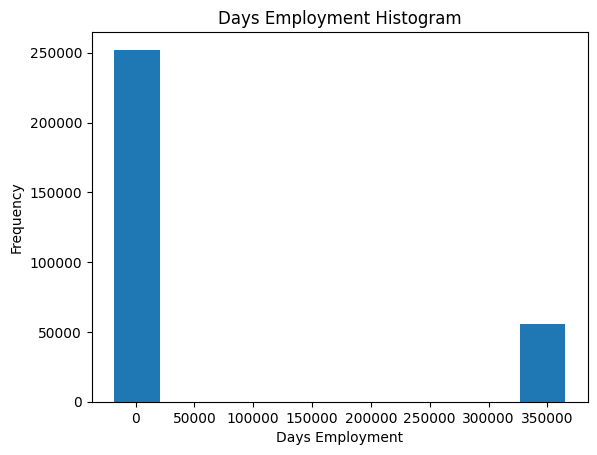

In [13]:
app_train['DAYS_EMPLOYED'].plot.hist(title = 'Days Employment Histogram');
plt.xlabel('Days Employment');

In [14]:
anom = app_train[app_train['DAYS_EMPLOYED'] == 365243]
non_anom = app_train[app_train['DAYS_EMPLOYED'] != 365243]
print('ceux qui n\'ont pas anomalie de jours d\'emplois sont en défaut de  %0.2f%% sur leur pret' % (100 * non_anom['TARGET'].mean()))
print('ceux qui ont des anomalies %0.2f%% sur leur pret' % (100 * anom['TARGET'].mean()))
print('Il y a  %d de jours en anomalie d\'emploi' % len(anom))

ceux qui n'ont pas anomalie de jours d'emplois sont en défaut de  8.66% sur leur pret
ceux qui ont des anomalies 5.40% sur leur pret
Il y a  55374 de jours en anomalie d'emploi


**Anomalie DAYS_EMPLOYED : Les clients avec la valeur 365243 représentent les sans-emploi. Paradoxalement, ils ont un taux de défaut plus bas que les autres — ce qui prouve que cette valeur est un code artificiel et doit être remplacée par NaN avant la modélisation.**

## b. Les corrélations

Maintenant que nous avons traité les variables catégorielles et les valeurs aberrantes, continuons l'EDA. Une façon de mieux comprendre les données est de chercher des corrélations entre les features et la cible. On peut calculer le coefficient de corrélation de Pearson entre chaque variable et la cible avec la méthode `.corr`.

Le coefficient de corrélationdonne une idée des relations possibles dans les données.  
Voici une interprétation des valeurs :

- .00-.19 → "très faible"
- .20-.39 → "faible"
- .40-.59 → "modérée"
- .60-.79 → "forte"
- .80-1.0 → "très forte"

In [15]:
# Find correlations with the target and sort
correlations = app_train.corr()['TARGET'].sort_values()

# Display correlations
print('Most Positive Correlations:\n', correlations.tail(15))
print('\nMost Negative Correlations:\n', correlations.head(15))

Most Positive Correlations:
 DAYS_REGISTRATION                                    0.041975
OCCUPATION_TYPE_Laborers                             0.043019
FLAG_DOCUMENT_3                                      0.044346
REG_CITY_NOT_LIVE_CITY                               0.044395
FLAG_EMP_PHONE                                       0.045982
NAME_EDUCATION_TYPE_Secondary / secondary special    0.049824
REG_CITY_NOT_WORK_CITY                               0.050994
DAYS_ID_PUBLISH                                      0.051457
CODE_GENDER_M                                        0.054713
DAYS_LAST_PHONE_CHANGE                               0.055218
NAME_INCOME_TYPE_Working                             0.057481
REGION_RATING_CLIENT                                 0.058899
REGION_RATING_CLIENT_W_CITY                          0.060893
DAYS_BIRTH                                           0.078239
TARGET                                               1.000000
Name: TARGET, dtype: float64

Most Negati

Corrélations positives (facteurs de risque) et Corrélations négatives (facteurs protecteurs)  

 **les déductions :**  
 -> facteurs de risque :
 - clients plus jeunes font plus souvent défaut  
 - vivre dans une région mal notée = plus risqué
 - Changer souvent de téléphone = instabilité
 
 -> facteurs protecteur
 - EXT_SOURCE_1/2/3 : Score externe de crédit élevé = client fiable
 - les diplômés du supérieur remboursent mieux.
 - Les femmes sont meilleures payeuses

Toutes ces corrélations sont très faibles (< 0.2), donc aucune variable seule n'est très prédictive. C'est pour ça qu'on utilisera un modèle ML plutôt qu'une simple régression linéaire. On va regarder les EXT_SOURCE qui sont les variables les + prédictives.

### 1)Effet de l'age sur le remboursement

In [16]:
# Find the correlation of the positive days since birth and target
app_train['DAYS_BIRTH'] = abs(app_train['DAYS_BIRTH'])
app_train['DAYS_BIRTH'].corr(app_train['TARGET'])

np.float64(-0.07823930830982709)

DAYS_BIRTH a une corrélation de -0.078 avec TARGET — corrélation négative : plus le client est âgé, plus il rembourse bien son prêt.

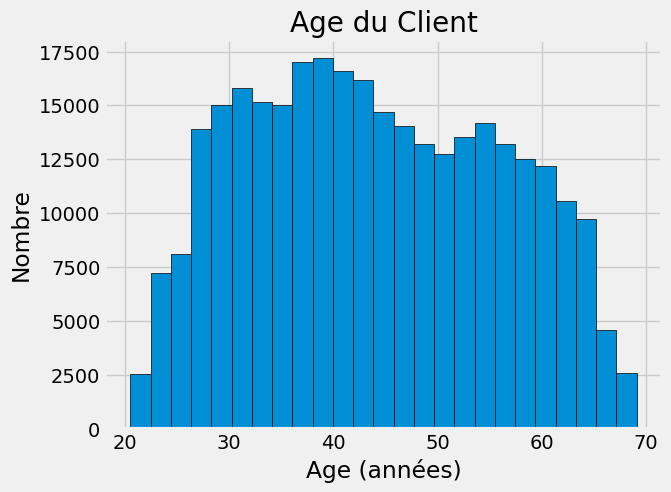

In [17]:
# Set the style of plots
plt.style.use('fivethirtyeight')

# Plot the distribution of ages in years
plt.hist(app_train['DAYS_BIRTH'] / 365, edgecolor = 'k', bins = 25)
plt.title('Age du Client'); plt.xlabel('Age (années)'); plt.ylabel('Nombre');

**KDE plot (Kernel Density Estimation)
La distribution de l'âge seul n'apprend pas grand chose — pas d'outliers, toutes les valeurs sont cohérentes. Pour voir l'effet de l'âge sur le remboursement, on trace un KDE coloré par la valeur de TARGET.
Un KDE est un histogramme lissé : il calcule une courbe gaussienne à chaque point de données, puis fait la moyenne de toutes ces courbes pour obtenir une courbe unique et continue.**

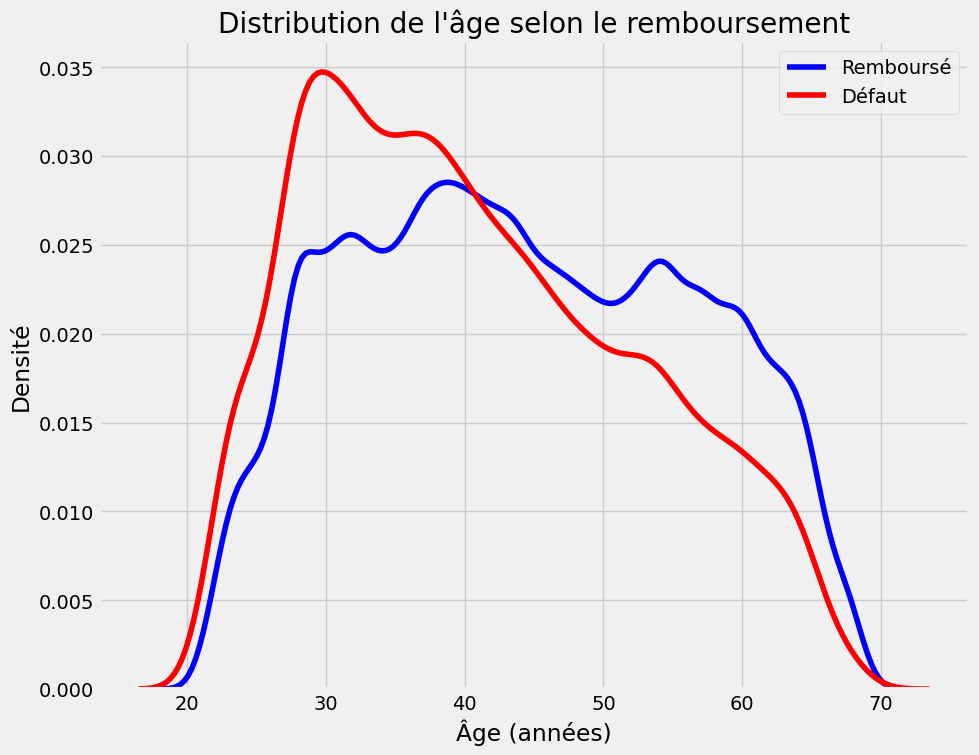

In [18]:
plt.figure(figsize=(10, 8))

# KDE pour chaque valeur de TARGET
for val, label, color in [(0, 'Remboursé', 'blue'), (1, 'Défaut', 'red')]:
    subset = app_train[app_train['TARGET'] == val]
    sns.kdeplot(abs(subset['DAYS_BIRTH']) / 365, label=label, color=color)

plt.xlabel('Âge (années)')
plt.ylabel('Densité')
plt.title('Distribution de l\'âge selon le remboursement')
plt.legend()
plt.show()

/var/folders/tc/d7sx2drn7hn1b805l3sxnmlm0000gn/T/ipykernel_28207/2019505812.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_groups = app_train.groupby('YEARS_BINNED')['TARGET'].mean()


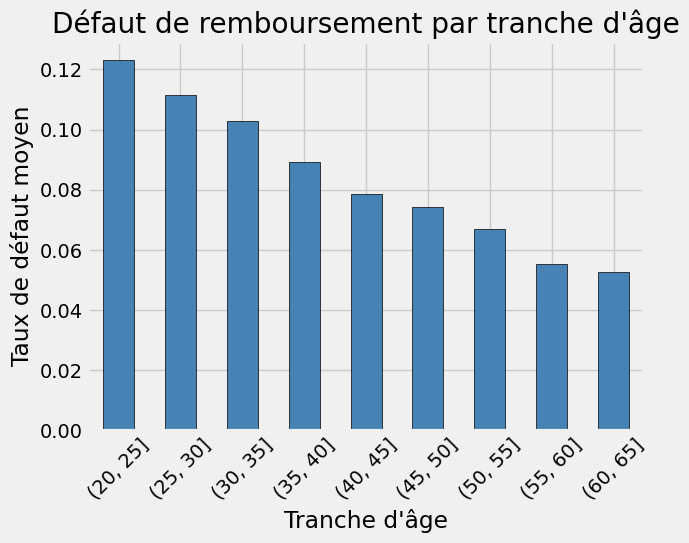

In [19]:
# Créer la colonne âge en années
app_train['YEARS_BIRTH'] = abs(app_train['DAYS_BIRTH']) / 365

# Découper en tranches de 5 ans
app_train['YEARS_BINNED'] = pd.cut(app_train['YEARS_BIRTH'], bins=np.arange(20, 70, 5))

# Taux de défaut moyen par tranche
age_groups = app_train.groupby('YEARS_BINNED')['TARGET'].mean()

# Visualisation
age_groups.plot(kind='bar', color='steelblue', edgecolor='k')
plt.xlabel('Tranche d\'âge')
plt.ylabel('Taux de défaut moyen')
plt.title('Défaut de remboursement par tranche d\'âge')
plt.xticks(rotation=45)
plt.show()

**Résultat & interprétation
La tendance est claire : les clients les plus jeunes remboursent moins bien. Le taux de défaut dépasse 10% pour les 3 tranches les plus jeunes, et tombe sous 5% pour les plus âgés.
Cette information est directement exploitable par la banque : plutôt que de discriminer les jeunes clients, elle pourrait leur proposer un accompagnement financier ou des conseils de gestion budgétaire pour les aider à rembourser dans les délais.**

### 2)EXT_SOURCE — Sources externes

**Les 3 variables avec la corrélation négative la plus forte avec TARGET sont EXT_SOURCE_1, EXT_SOURCE_2 et EXT_SOURCE_3. D'après la documentation, elles représentent un "score normalisé issu de sources de données externes" — probablement un score de crédit cumulatif calculé à partir de plusieurs sources (type scoring bancaire).
On commence par afficher les corrélations entre ces features, entre elles et avec TARGET :**

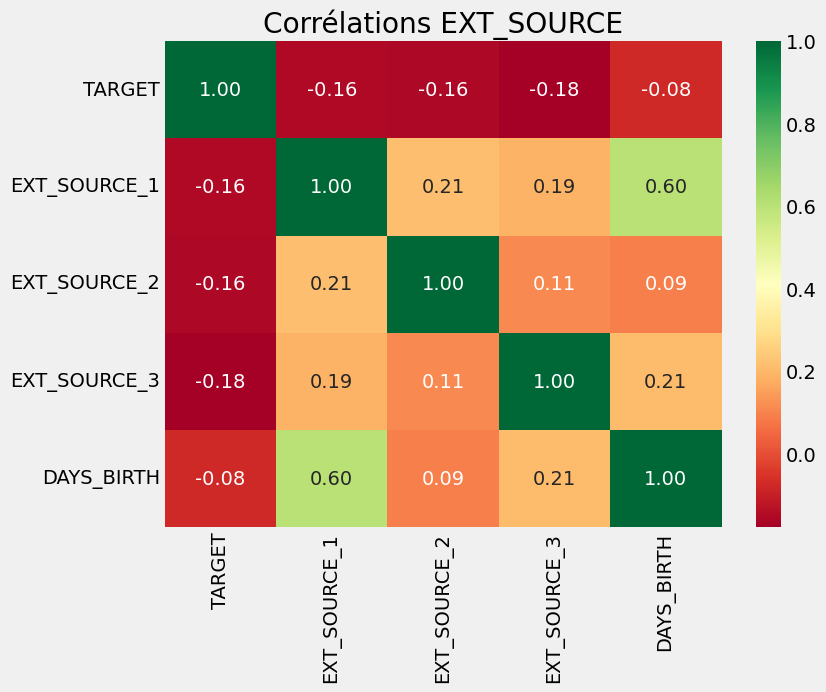

In [20]:
# Corrélations EXT_SOURCE avec TARGET et entre elles
ext_data = app_train[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']]
ext_corr = ext_data.corr()

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(ext_corr, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Corrélations EXT_SOURCE')
plt.show()

**Interprétation de la heatmap**  
Les 3 scores EXT_SOURCE ont une corrélation négative avec TARGET : plus le score est élevé, plus le client a de chances de rembourser.  
On remarque aussi que DAYS_BIRTH est positivement corrélé avec EXT_SOURCE_1, ce qui suggère que l'âge du client est peut-être l'un des facteurs pris en compte dans ce score.  
Pour aller plus loin, on trace un KDE pour chaque EXT_SOURCE, coloré par TARGET :

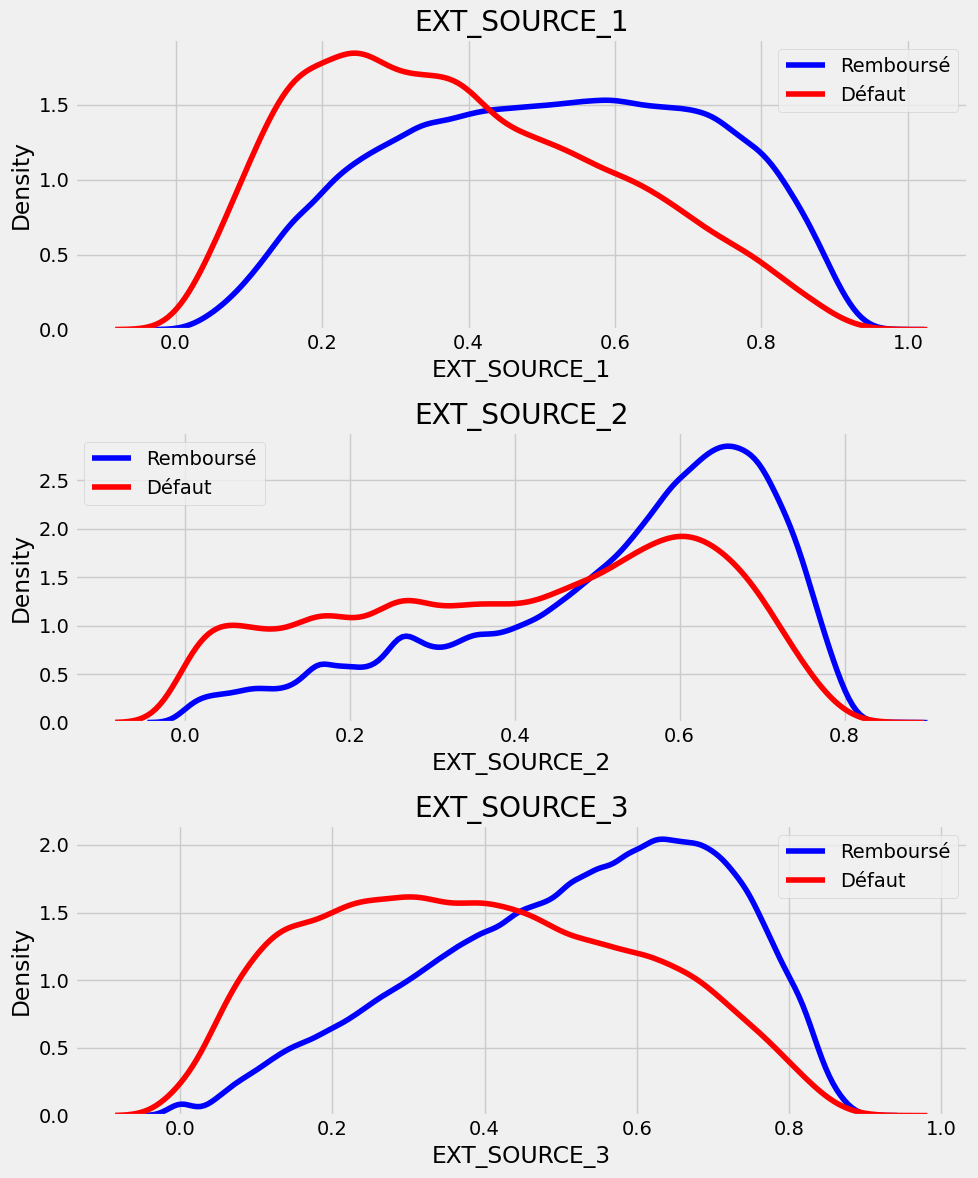

In [21]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

for i, source in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    for val, label, color in [(0, 'Remboursé', 'blue'), (1, 'Défaut', 'red')]:
        subset = app_train[app_train['TARGET'] == val]
        sns.kdeplot(subset[source].dropna(), ax=axes[i], label=label, color=color)
    axes[i].set_title(source)
    axes[i].legend()

plt.tight_layout()
plt.show()

**Résultat des KDE — EXT_SOURCE  
EXT_SOURCE_3 montre la différence la plus marquée entre les deux courbes — c'est la variable externe la plus discriminante. Malgré tout, les 3 scores restent des corrélations très faibles au sens statistique. Elles seront néanmoins utiles dans un modèle ML pour prédire le remboursement, car même une faible corrélation linéaire peut cacher une relation plus complexe qu'un algorithme saura exploiter.**

#### Feature EXT_SOURCE  
Les 3 scores se complètent — ils ne mesurent pas exactement la même chose


In [22]:
print("-"*40)
print("La moyenne des 3 variables :")
app_train['EXT_SOURCE_MEAN'] = app_train[['EXT_SOURCE_1', 
                                           'EXT_SOURCE_2', 
                                           'EXT_SOURCE_3']].mean(axis=1)

# Corrélation du score combiné
print(app_train['EXT_SOURCE_MEAN'].corr(app_train['TARGET'], method='spearman'))

----------------------------------------
La moyenne des 3 variables :
-0.20433988946561343


In [23]:
print("-"*40)
print("La moyenne des minimum des 3 variables :")
app_train['EXT_SOURCE_MIN'] = app_train[['EXT_SOURCE_1', 
                                          'EXT_SOURCE_2', 
                                          'EXT_SOURCE_3']].min(axis=1)

print(app_train['EXT_SOURCE_MIN'].corr(app_train['TARGET'], method='spearman'))

----------------------------------------
La moyenne des minimum des 3 variables :
-0.18025815616804927


In [24]:
print("-"*40)
print("La moyenne Pondéré en donnant + de poid à EXT_SOURCE_3 : ")
app_train['EXT_SOURCE_WEIGHTED'] = (
    app_train['EXT_SOURCE_1'] * 0.25 +
    app_train['EXT_SOURCE_2'] * 0.35 +
    app_train['EXT_SOURCE_3'] * 0.40
)

print(app_train['EXT_SOURCE_WEIGHTED'].corr(app_train['TARGET'], method='spearman'))

----------------------------------------
La moyenne Pondéré en donnant + de poid à EXT_SOURCE_3 : 
-0.2173301035832064


---

** Analyse :**  
-> La moyenne pondéré est la meilleure feature.  
Donner plus de poids à EXT_SOURCE_3 (le plus discriminant) améliore le signal — la pondération 25/35/40 est meilleure que l'égale répartition.**

---

### 3) Nouvelles Features

In [25]:
# Ratio d'endettement : part du revenu consacrée au remboursement
app_train['ANNUITY_INCOME_RATIO'] = app_train['AMT_ANNUITY'] / app_train['AMT_INCOME_TOTAL']

# Ratio prêt/bien : est-ce que le prêt couvre bien le prix du bien ?
app_train['CREDIT_GOODS_RATIO'] = app_train['AMT_CREDIT'] / app_train['AMT_GOODS_PRICE']

# Âge en années (DAYS_BIRTH est négatif)
app_train['AGE_YEARS'] = app_train['DAYS_BIRTH'] / -365

# Ancienneté dans l'emploi en années
app_train['EMPLOYED_YEARS'] = app_train['DAYS_EMPLOYED'] / -365

# Ratio crédit/revenu : combien d'années de revenu pour rembourser ?
app_train['CREDIT_INCOME_RATIO'] = app_train['AMT_CREDIT'] / app_train['AMT_INCOME_TOTAL']

In [26]:
new_features = ['ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO', 
                'AGE_YEARS', 'EMPLOYED_YEARS', 'CREDIT_INCOME_RATIO']

corr_new = app_train[new_features + ['TARGET']].corr(method='spearman')['TARGET'].sort_values()
print(corr_new)

EMPLOYED_YEARS         -0.025182
CREDIT_INCOME_RATIO    -0.001798
ANNUITY_INCOME_RATIO    0.018432
CREDIT_GOODS_RATIO      0.066809
AGE_YEARS               0.078328
TARGET                  1.000000
Name: TARGET, dtype: float64


**Analyse:**  
**AGE_YEARS et CREDIT_GOODS_RATIO sont les plus intéressants à garder**

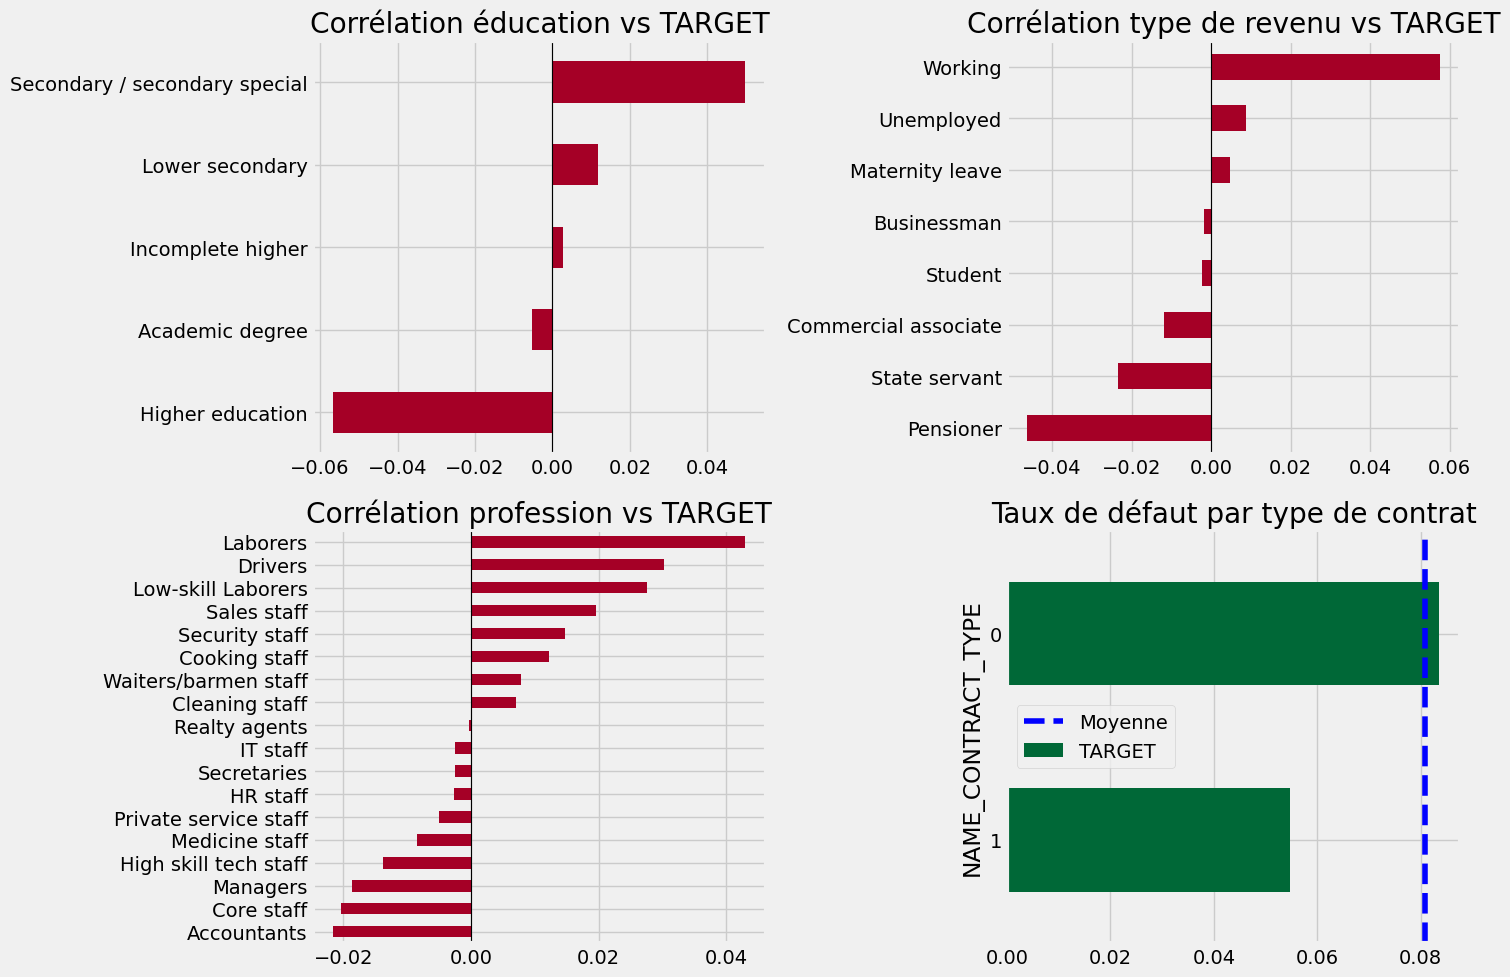

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# === ÉDUCATION ===
edu_cols = [c for c in app_train.columns if 'NAME_EDUCATION_TYPE' in c]
edu_means = app_train[edu_cols + ['TARGET']].corr(method='spearman')['TARGET'].drop('TARGET')
edu_means.index = [c.replace('NAME_EDUCATION_TYPE_', '') for c in edu_means.index]
edu_means.sort_values().plot(kind='barh', ax=axes[0,0], colormap='RdYlGn')
axes[0,0].set_title('Corrélation éducation vs TARGET')
axes[0,0].axvline(0, color='black', linewidth=0.8)

# === TYPE DE REVENU ===
income_cols = [c for c in app_train.columns if 'NAME_INCOME_TYPE' in c]
income_means = app_train[income_cols + ['TARGET']].corr(method='spearman')['TARGET'].drop('TARGET')
income_means.index = [c.replace('NAME_INCOME_TYPE_', '') for c in income_means.index]
income_means.sort_values().plot(kind='barh', ax=axes[0,1], colormap='RdYlGn')
axes[0,1].set_title('Corrélation type de revenu vs TARGET')
axes[0,1].axvline(0, color='black', linewidth=0.8)

# === PROFESSION ===
occ_cols = [c for c in app_train.columns if 'OCCUPATION_TYPE' in c]
occ_means = app_train[occ_cols + ['TARGET']].corr(method='spearman')['TARGET'].drop('TARGET')
occ_means.index = [c.replace('OCCUPATION_TYPE_', '') for c in occ_means.index]
occ_means.sort_values().plot(kind='barh', ax=axes[1,0], colormap='RdYlGn')
axes[1,0].set_title('Corrélation profession vs TARGET')
axes[1,0].axvline(0, color='black', linewidth=0.8)

# === TYPE DE CONTRAT ===
contract_means = app_train.groupby('NAME_CONTRACT_TYPE')['TARGET'].mean().sort_values()
contract_means.plot(kind='barh', ax=axes[1,1], colormap='RdYlGn_r')
axes[1,1].set_title('Taux de défaut par type de contrat')
axes[1,1].axvline(app_train['TARGET'].mean(), color='blue', linestyle='--', label='Moyenne')
axes[1,1].legend()

plt.tight_layout()
plt.show()

In [28]:
# === NOUVELLES FEATURES À AJOUTER ===

# Ratios financiers
app_train['ANNUITY_INCOME_RATIO'] = app_train['AMT_ANNUITY'] / app_train['AMT_INCOME_TOTAL']
app_train['CREDIT_GOODS_RATIO'] = app_train['AMT_CREDIT'] / app_train['AMT_GOODS_PRICE']
app_train['CREDIT_INCOME_RATIO'] = app_train['AMT_CREDIT'] / app_train['AMT_INCOME_TOTAL']

# Âge et ancienneté
app_train['AGE_YEARS'] = app_train['DAYS_BIRTH'] / -365
app_train['EMPLOYED_YEARS'] = app_train['DAYS_EMPLOYED'] / -365

# EXT_SOURCE combinés
app_train['EXT_SOURCE_MEAN'] = app_train[['EXT_SOURCE_1', 
                                           'EXT_SOURCE_2', 
                                           'EXT_SOURCE_3']].mean(axis=1)
app_train['EXT_SOURCE_MIN'] = app_train[['EXT_SOURCE_1', 
                                          'EXT_SOURCE_2', 
                                          'EXT_SOURCE_3']].min(axis=1)
app_train['EXT_SOURCE_WEIGHTED'] = (
    app_train['EXT_SOURCE_1'] * 0.25 +
    app_train['EXT_SOURCE_2'] * 0.35 +
    app_train['EXT_SOURCE_3'] * 0.40
)

# Vérification
print(f"Shape du dataset : {app_train.shape}")
print("\nNouvelles colonnes ajoutées :")
new_cols = ['ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO', 'CREDIT_INCOME_RATIO',
            'AGE_YEARS', 'EMPLOYED_YEARS', 'EXT_SOURCE_MEAN', 
            'EXT_SOURCE_MIN', 'EXT_SOURCE_WEIGHTED']
print(app_train[new_cols].describe())

Shape du dataset : (307511, 253)

Nouvelles colonnes ajoutées :
       ANNUITY_INCOME_RATIO  CREDIT_GOODS_RATIO  CREDIT_INCOME_RATIO  \
count         307499.000000       307233.000000        307511.000000   
mean               0.180930            1.122995             3.957570   
std                0.094574            0.124045             2.689728   
min                0.000224            0.150000             0.004808   
25%                0.114782            1.000000             2.018667   
50%                0.162833            1.118800             3.265067   
75%                0.229067            1.198000             5.159880   
max                1.875965            6.000000            84.736842   

           AGE_YEARS  EMPLOYED_YEARS  EXT_SOURCE_MEAN  EXT_SOURCE_MIN  \
count  307511.000000   307511.000000    307339.000000    3.073390e+05   
mean      -43.936973     -174.835742         0.509251    3.995821e-01   
std        11.956133      387.056895         0.149802    1.874246e-0

# 5. Pairs Plot (graphique de paires)

**Pour terminer l'exploration, on crée un pairs plot combinant EXT_SOURCE_1/2/3 et DAYS_BIRTH. C'est un outil puissant qui affiche en une seule figure :**

**Diagonale → histogramme de chaque variable
Triangle supérieur → scatterplots entre chaque paire
Triangle inférieur → KDE 2D + coefficient de corrélation**

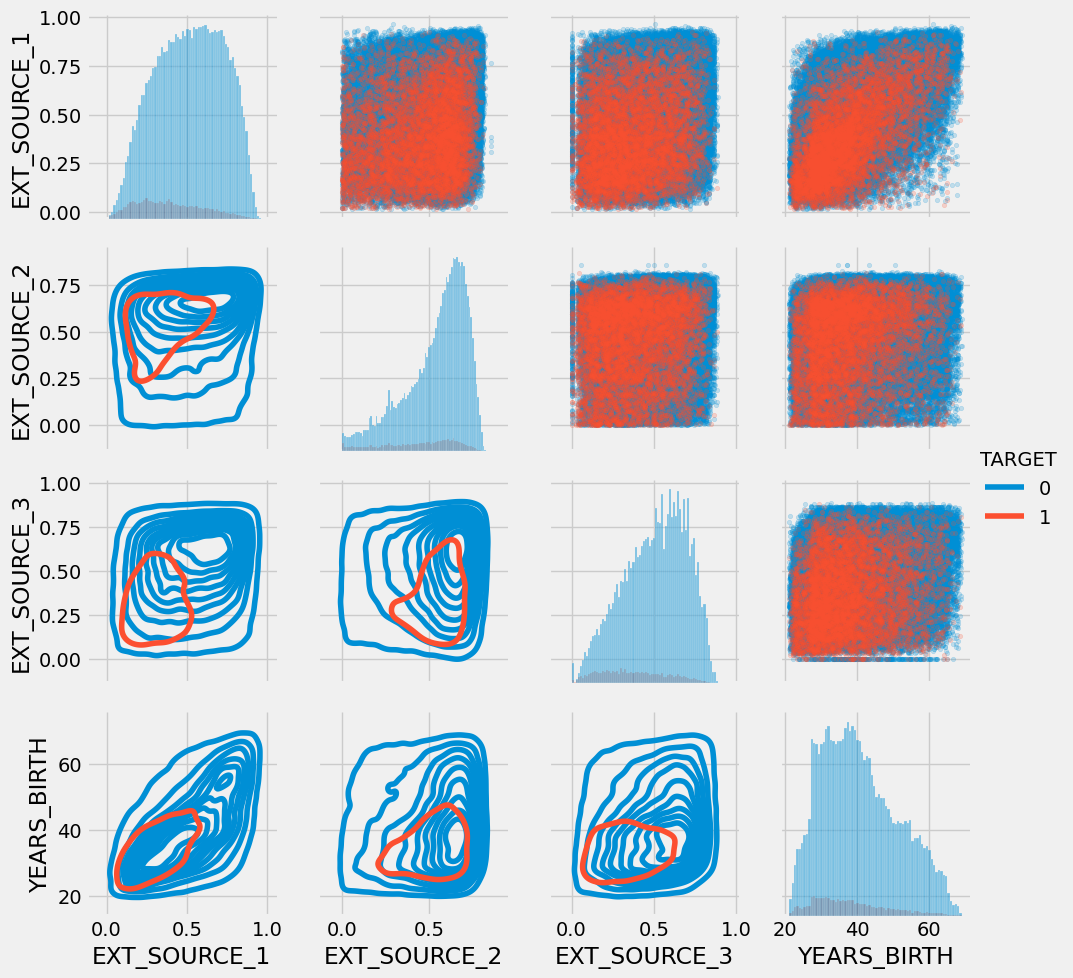

In [29]:
# Pairs plot
plot_data = app_train[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']].dropna()
plot_data['YEARS_BIRTH'] = abs(plot_data['DAYS_BIRTH']) / 365

g = sns.PairGrid(plot_data.drop(columns='DAYS_BIRTH'), hue='TARGET', diag_sharey=False)
g.map_upper(plt.scatter, alpha=0.2, s=10)
g.map_diag(sns.histplot)
g.map_lower(sns.kdeplot)
g.add_legend()
plt.show()

# 6.Enregistrement du Dataset

In [31]:
# Supprimer les colonnes temporaires d'exploration
cols_to_drop = ['YEARS_BINNED', 'YEARS_BIRTH']
app_train = app_train.drop(columns=[c for c in cols_to_drop if c in app_train.columns])

# Sauvegarde
app_train.to_parquet('app_train_clean.parquet', index=False)
print("✅ Sauvegardé !")
print(f"app_train_clean : {app_train.shape}")

✅ Sauvegardé !
app_train_clean : (307511, 251)


---
## ✅ Checklist — Étape 1

| Indicateur | Statut |
|---|---|
| Exploration données brutes | ✅ |
| Fusion train + test cohérente | ✅ |
| Suppression colonnes >40% NaN | ✅ |
| Correction anomalie DAYS_EMPLOYED | ✅ |
| Encodage variables catégorielles | ✅ |
| Nouvelles features métier | ✅ |
| Remplacement valeurs infinies | ✅ |
| Datasets sauvegardés en parquet | ✅ |